# Indexing 3: refine and build the adaptive basis (1 degree mosaicity)

1. Refine the pbp map: every peak is assigned a position along the beam
   (its diffraction origin), and the candidate grains of every voxel are
   refined against the peaks passing through it.
2. Segment the refined map into grains (flood fill on the best orientation) and sort the
   candidates of every voxel by completeness (unique peaks relative to the
   best voxel of the same grain).
3. Build the adaptive basis: all candidate orientations of all voxels, thinned so that
   no two orientations are closer than `theta_deg`. This is the orientation grid
   used in the texture tomography.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path

# make the repository importable, whatever the working directory is
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "simtools").is_dir())
sys.path.insert(0, str(REPO))

import os

import numpy as np
import matplotlib.pyplot as plt
import ImageD11.unitcell
import ImageD11.sinograms.point_by_point as pbp
from scipy.spatial.transform import Rotation as R
from diffractom import Grid
from simtools import dummy, io, orientations, paths, pbp_maps, plot

plot.dark()

In [2]:
SAMPLE = "domains_mosaicity_1p0deg"
savefile = os.path.join(paths.process_dir(SAMPLE), "peaks_2d")

colf = io.read_peaks(paths.peaks_path(SAMPLE))
ypositions, ystep, ymin, y0 = dummy.add_pbp_columns(colf)
dset = dummy.load_dset(savefile + "_dummy_dset.pkl")
dset.y0 = y0
pbpmap = pbp.PBPMap(savefile + "_pbpmap.h5")

Reading your columnfile in hdf format


In [3]:
pars = colf.parameters.parameters
ucell = ImageD11.unitcell.unitcell(
    [pars["cell__a"], pars["cell__b"], pars["cell__c"], pars["cell_alpha"], pars["cell_beta"], pars["cell_gamma"]],
    pars["cell_lattice_[P,A,B,C,I,F,R]"],
)
ucell.makerings(colf.ds.max())

In [4]:
multi_channel = pbp_maps.MultiChannelMap(pbpmap, ucell)
print(f"{multi_channel.nchannels} candidate grains (channels) per voxel at most")

10 candidate grains (channels) per voxel at most


## Refinement

In [5]:
dset.refmapfile = savefile + "_pbpmap.h5"  # pbp map input
dset.refpeaksfile = savefile + "_icolfile_refine.h5"  # peaks with diffraction origins
dset.refoutfile = savefile + "_pbpmap_refine.h5"  # refined pbp map
dset.refmanfile = savefile + "_pbprefiner.h5"  # the refiner itself

eta_wedge = 6
etacut = np.abs(np.sin(np.radians(eta_wedge)))
ifrac = colf.sum_intensity.min() / colf.sum_intensity.max()  # use all peaks

refiner = pbp.PBPRefine(
    dset,
    phase_name=None,
    hkl_tol_origins=0.15,
    hkl_tol_refine=0.15,
    hkl_tol_refine_merged=0.15,
    ds_tol=0.01,
    etacut=etacut,
    ifrac=ifrac,
    forref=None,
    y0=y0,
    min_grain_npks=10,
)
refiner.setmap(pbpmap)
refiner.setpeaks(colf, del_existing=True, prompt_del=False)

0 0.4277 (1, 1, 1) 8 9143 used, sum_intensity> 2.0
1 0.4939 (0, 2, 0) 6 6520 used, sum_intensity> 0.7445872912428988
2 0.6985 (2, 0, 2) 12 13739 used, sum_intensity> 0.6172890705742178
3 0.8191 (1, 3, 1) 24 27474 used, sum_intensity> 0.7696513089901323
4 0.8555 (2, 2, 2) 8 9760 used, sum_intensity> 0.47519929432365005
5 0.9878 (0, 4, 0) 6 7023 used, sum_intensity> 0.1268538815490649
6 1.0765 (3, 3, 1) 24 29430 used, sum_intensity> 0.23773788599903892
7 1.1044 (0, 4, 2) 24 29486 used, sum_intensity> 0.18385107069270823
8 1.2098 (4, 2, 2) 24 31501 used, sum_intensity> 0.1556898447117062
9 1.2832 (3, 3, 3) 32 39145 used, sum_intensity> 0.06999822264352154
10 1.3970 (4, 4, 0) 12 15202 used, sum_intensity> 0.049351264885360506
11 1.4610 (3, 5, 1) 48 60581 used, sum_intensity> 0.034214112210439004
12 1.4817 (4, 2, 4) 30 37787 used, sum_intensity> 0.04262364147428428
13 1.5619 (2, 6, 0) 24 29214 used, sum_intensity> 0.022388108826878896
14 1.6194 (5, 3, 3) 24 28899 used, sum_intensity> 0.0154

33 2.4572 (3, 9, 3) 72 1353 used, sum_intensity> 8.88678239232182e-05
34 2.4696 (6, 0, 8) 30 499 used, sum_intensity> 7.241081949299261e-05
35 2.5185 (10, 0, 2) 72 238 used, sum_intensity> 5.924521594881213e-05
36 2.5545 (3, 7, 7) 72 113 used, sum_intensity> 3.6205409746496305e-05
37 2.5664 (6, 6, 6) 32 5 used, sum_intensity> 6.582801772090237e-06
Using for refinement: 895177 npks, forref 1242 range(0, 38)


The sample mask: voxels whose reconstructed peak intensity is above `manual_threshold`.

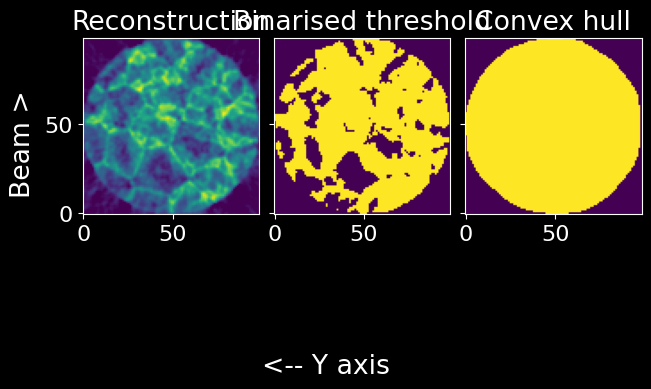

In [6]:
refiner.setmask(manual_threshold=0.22, doplot=True, use_icolf=True)

Diffraction origins are computed from the best candidate of every voxel.

Getting gvecs...
Lexsort...
Running numba computation on 31 threads, may take a while!


xpos_refined column added to self.icolf
Saving self.icolf to disk with new column


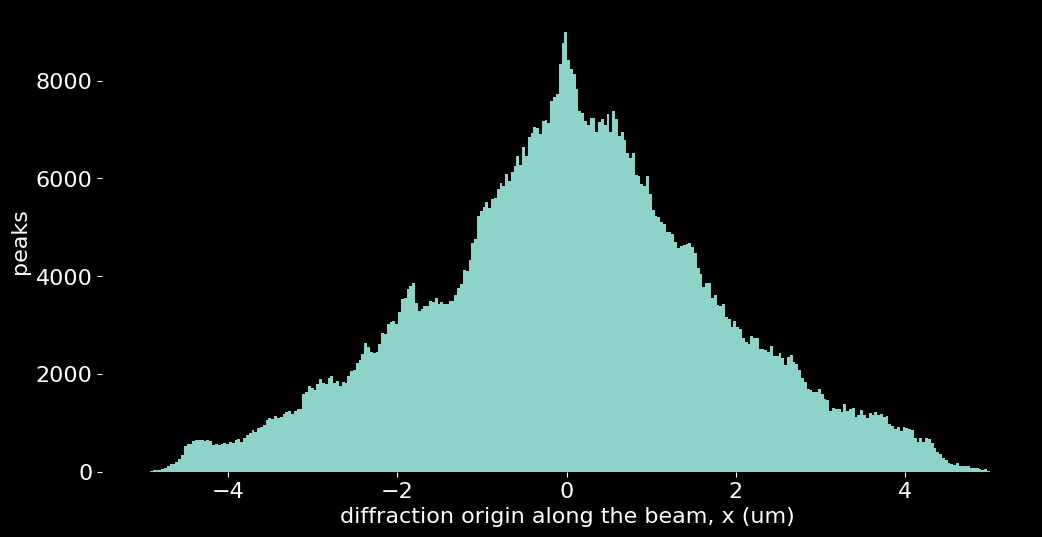

In [7]:
refiner.singlemap = multi_channel.ubi[:, :, 0]
refiner.get_origins(guess_speed=False, save_peaks_after=True)

xpos = refiner.icolf.xpos_refined[refiner.icolf.isel] if hasattr(refiner.icolf, "isel") else refiner.icolf.xpos_refined
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.hist(xpos, bins=300)
ax.set_xlabel("diffraction origin along the beam, x (um)")
ax.set_ylabel("peaks")
plot.despine(ax)
plt.show()

In [8]:
output_filename = savefile + "_refined_pbpmap.h5"
if os.path.isfile(output_filename):
    os.remove(output_filename)
refiner.run_refine(points_step_space=None, npoints=None, output_filename=output_filename, use_cluster=False, pythonpath=None)

Launching Numba parallel refinement on 31 threads


Saving refined map to disk


Reading your columnfile in hdf format


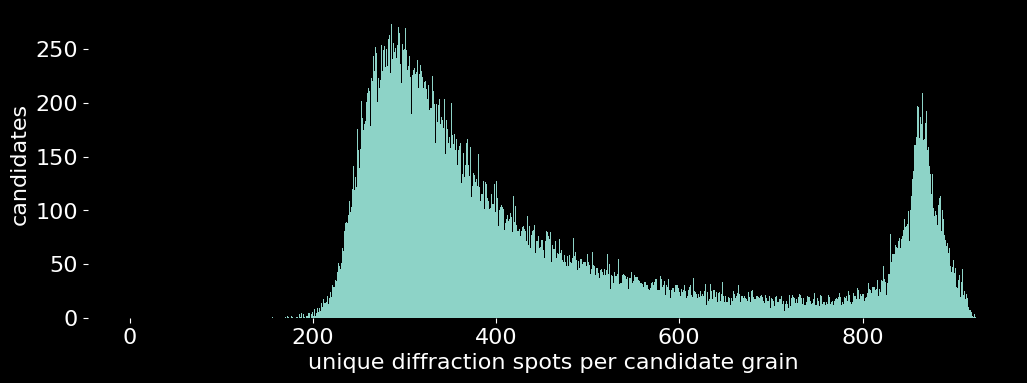

In [9]:
refined_pbpmap = pbp.PBPMap(refiner.refinedmap_filename)
refined = pbp_maps.MultiChannelMap(refined_pbpmap, ucell)

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(refined_pbpmap.nuniq, bins=np.arange(0.5, np.max(refined_pbpmap.nuniq) + 0.51, 1))
ax.set_xlabel("unique diffraction spots per candidate grain")
ax.set_ylabel("candidates")
plot.despine(ax)
plt.show()

## Grain segmentation and completeness

In [10]:
segmap = pbp_maps.segment_grains(
    refined,
    refiner.mask,
    local_disorientation_tolerance=2,  # deg, between neighbouring voxels
    max_grains=99,
    min_grain_size=5,  # voxels
    seed=0,
)
refined.normalize_per_grain(segmap)
refined.sort()  # by completeness, then total peaks
print(f"{int(np.nanmax(segmap))} grains")

20 grains


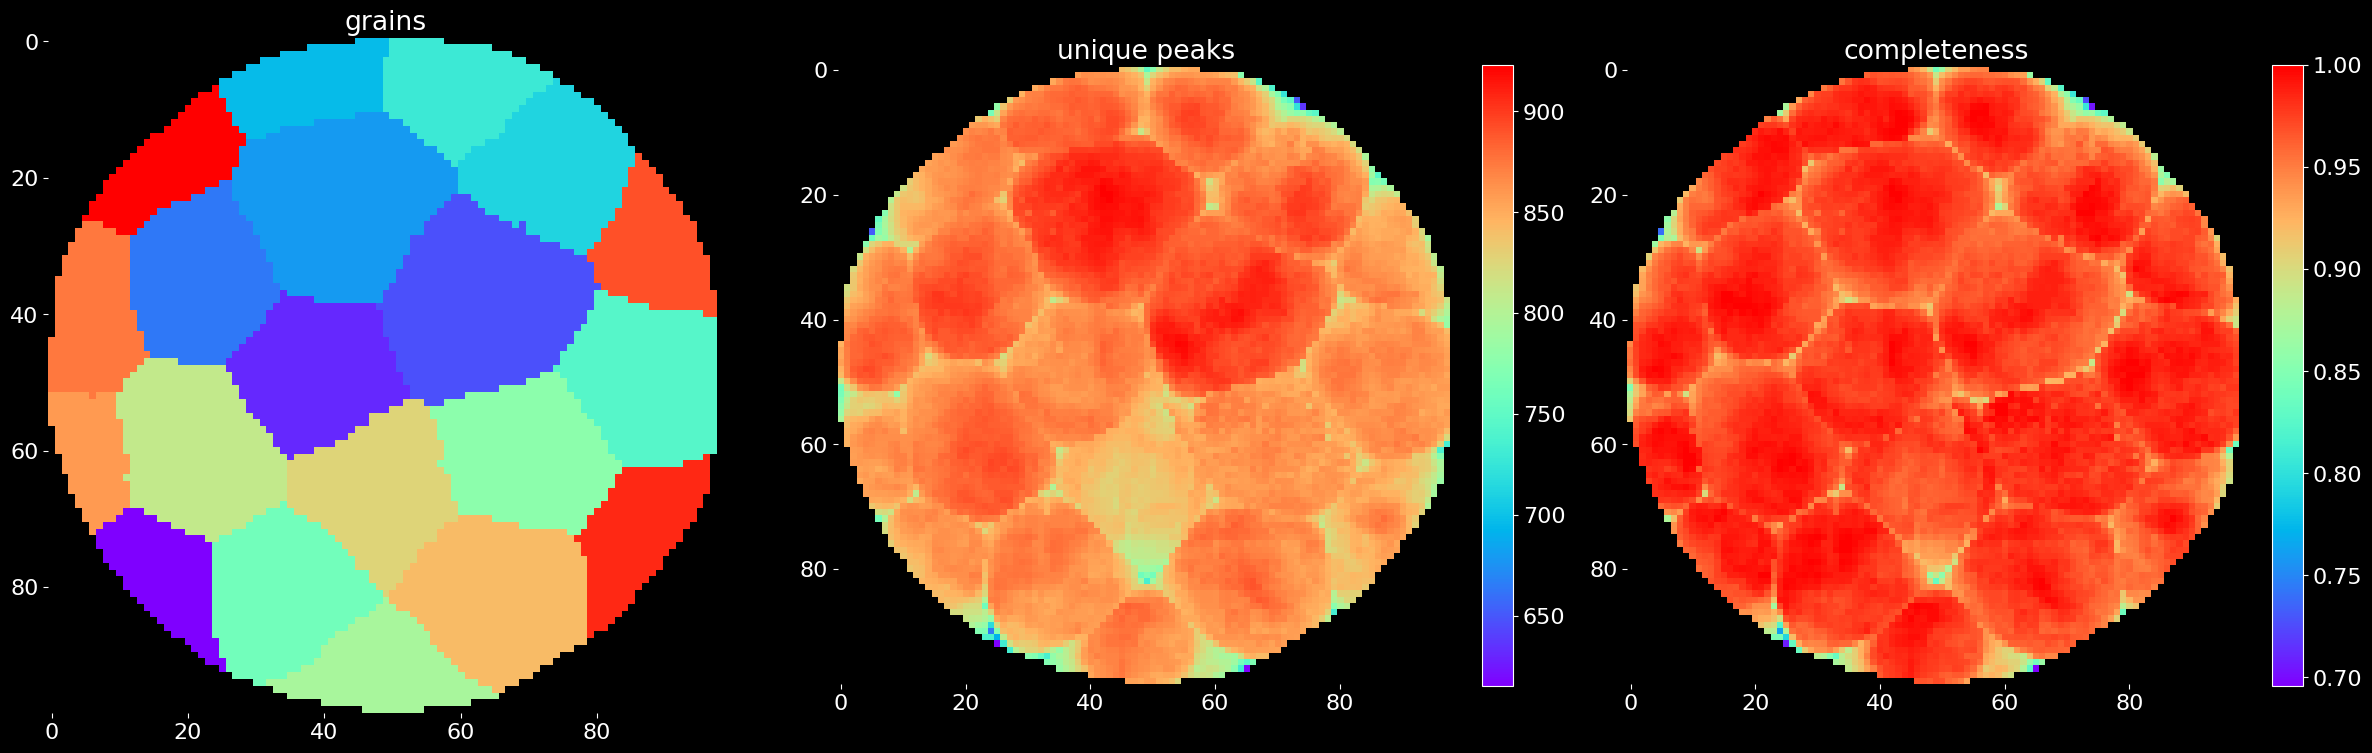

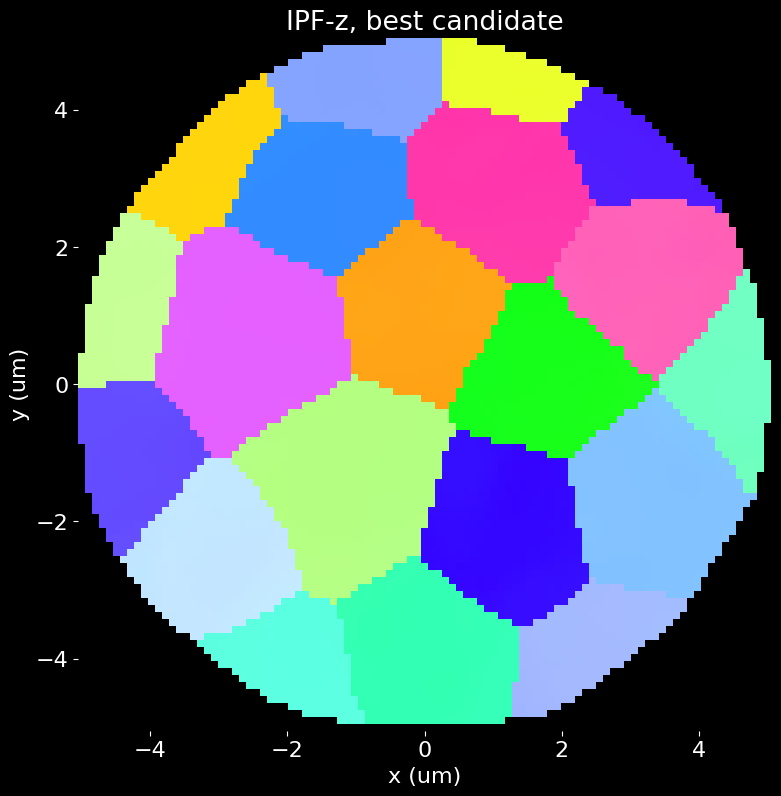

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(24, 8))
ax[0].imshow(segmap, cmap="rainbow")
ax[0].set_title("grains")
for a, (field, title) in zip(ax[1:], [(refined.nuniq[:, :, 0], "unique peaks"), (refined.completeness[:, :, 0], "completeness")]):
    _s = field.copy()
    _s[~refiner.mask] = np.nan
    im = a.imshow(_s, cmap="rainbow")
    a.set_title(title)
    fig.colorbar(im, ax=a, fraction=0.046, pad=0.04)
plot.despine(ax)
plt.tight_layout()
plt.show()

_s = refined.rgb[:, :, 0, 2].copy()
_s[~refiner.mask] = np.nan
fig, ax = plt.subplots(1, 1, figsize=(9, 9))
ax.pcolormesh(dset.sx_grid, dset.sy_grid, _s)
ax.set_aspect("equal")
ax.set_title("IPF-z, best candidate")
ax.set_xlabel("x (um)")
ax.set_ylabel("y (um)")
plot.despine(ax)
plt.show()

## Build the adaptive basis

All candidate orientations of all voxels, in the order of the sorted map, are
thinned greedily: an orientation is kept unless it is within `theta_deg` of one
already kept (`diffractom.Grid.prune_close_orientations`).

In [12]:
theta_deg = 0.2

u = refined.u.reshape(-1, 3, 3)
u = u[np.any(u != 0, axis=(1, 2))]  # drop empty channels
print(f"{len(u)} candidate orientations")

grid = Grid.from_rotation_matrices(u, sigma=np.deg2rad(theta_deg))  # sigma is not used for pruning
grid.prune_close_orientations(theta_deg=theta_deg)
basis = R.concatenate(grid.rotations_at_level(0)).as_matrix()
print(f"adaptive basis: {len(basis)} orientations")

os.makedirs(os.path.dirname(paths.basis_path(SAMPLE)), exist_ok=True)
np.save(paths.basis_path(SAMPLE), basis)
print("saved", paths.basis_path(SAMPLE))

67049 candidate orientations


adaptive basis: 345 orientations
saved /dtu-compute/msaca/adaptive_basis_simulations/adaptive_basis/domains_mosaicity_1p0deg/basis.npy


## Comparison with the ground truth
The misorientation from each ground-truth mesh element to the closest basis orientation.

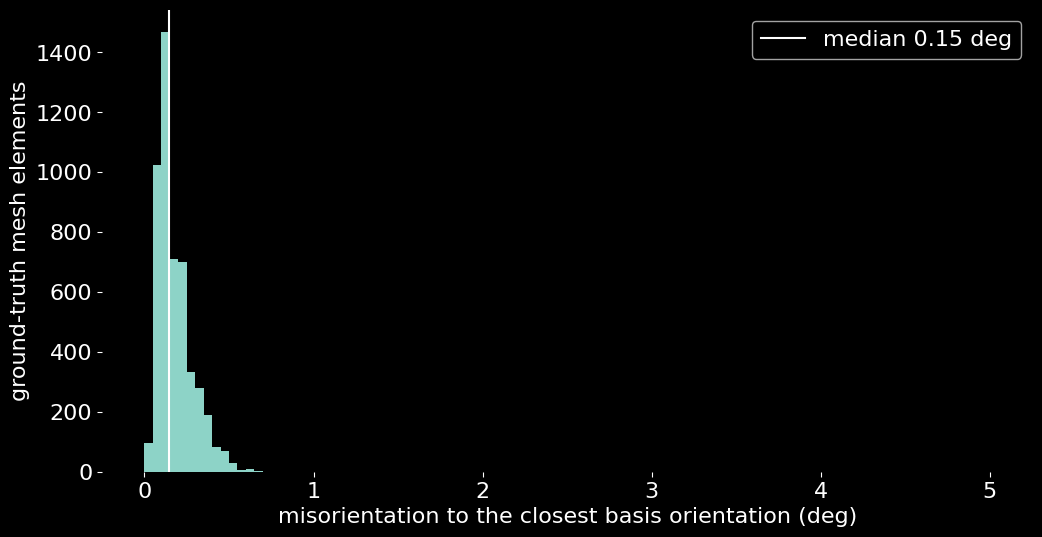

In [13]:
gt = io.read_ground_truth(SAMPLE)
idx = np.random.default_rng(0).choice(len(gt["orientation"]), 5000, replace=False)
mis = orientations.min_misorientation_deg(gt["orientation"][idx], basis)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.hist(mis, bins=100, range=(0, max(5, np.percentile(mis, 99))))
ax.axvline(np.median(mis), c="w", label=f"median {np.median(mis):.2f} deg")
ax.set_xlabel("misorientation to the closest basis orientation (deg)")
ax.set_ylabel("ground-truth mesh elements")
ax.legend()
plot.despine(ax)
plt.show()

## Save the point-by-point orientation map
The pbp map shown in the figures (`visualization/`), per voxel:

* `best`: the best candidate, after sorting by completeness (the article's 1 deg figure);
* `filtered`: the candidate whose IPF colours (x, y and z) are closest to the 3 x 3 median of the
  best candidates' colours, which replaces isolated wrong picks (the article's 10 deg figure);
* `mask`: the sample mask of the refinement.

In [ ]:
from scipy.ndimage import median_filter

present = np.any(refined.u != 0, axis=(-2, -1))                      # (NY, NY, channels)
smooth_rgb = median_filter(refined.rgb[:, :, 0], size=(3, 3, 1, 1))  # median of the best candidates' colours
distance = np.linalg.norm(refined.rgb - smooth_rgb[:, :, None], axis=(-2, -1))
distance[~present] = np.inf
choice = np.argmin(distance, axis=-1)
filtered = np.take_along_axis(refined.u, choice[:, :, None, None, None], axis=2)[:, :, 0]
print(f"filtered map differs from the best candidate in {100 * np.mean(choice[refiner.mask] != 0):.1f}% of the sample")

pbp_map_path = os.path.join(paths.process_dir(SAMPLE), "pbp_map.npz")
np.savez(pbp_map_path, best=refined.u[:, :, 0], filtered=filtered, mask=refiner.mask,
         sx=dset.sx_grid, sy=dset.sy_grid)
print("saved", pbp_map_path)